# Grids, Parametrized Grids & Torus - Embedding Visualisation

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from vis import (
    load_token_id_map,
    load_grid_structure,
    load_embeddings_pt,
    load_embeddings_batch,
    grid_edges_from_grid,
    torus_edges_from_grid,
    plot_pca_on_ax,
    plot_pca_3d_on_ax,
    plot_umap_on_ax,
)

## Grid 4×4 (uncorrelated tokens)

In [2]:
ROW_COLORS = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
CTX_LENS = [300, 600, 1200, 1800]

VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
GRID_PATH  = Path("../data/one_random_walk/grid_16/grid_dataset_structure.txt")
EMB_DIR    = Path("../embeddings/one_random_walk/grid_16")

token_to_id, _ = load_token_id_map(VOCAB_PATH)
GRID, WORD_TO_POS, WORD_TO_TID, ID_TO_WORD, ROW_LABELS = \
    load_grid_structure(GRID_PATH, token_to_id)

all_edges = grid_edges_from_grid(GRID, WORD_TO_TID)
ROW_COLORS_MAP = {i: c for i, c in enumerate(ROW_COLORS)}
ROW_LABELS_MAP = {r: f"Row {r}: " + " ".join(GRID[r]) for r in range(4)}
token_to_group = {w: r for r, row in enumerate(GRID) for c, w in enumerate(row)}

print("GRID:")
for row in GRID:
    print(row)
print(f"\nRow labels: {list(ROW_LABELS_MAP.values())}")

GRID:
['blackout', 'mafia', 'flu', 'lexical']
['nonatomic', 'beverage', 'albums', 'crappy']
['potassium', 'phoenix', 'grinder', 'standby']
['peanuts', 'undergrad', 'culprit', 'vitae']

Row labels: ['Row 0: blackout mafia flu lexical', 'Row 1: nonatomic beverage albums crappy', 'Row 2: potassium phoenix grinder standby', 'Row 3: peanuts undergrad culprit vitae']


  [Grid - ctx 300] Discarded 3/302 embeddings with unknown token IDs


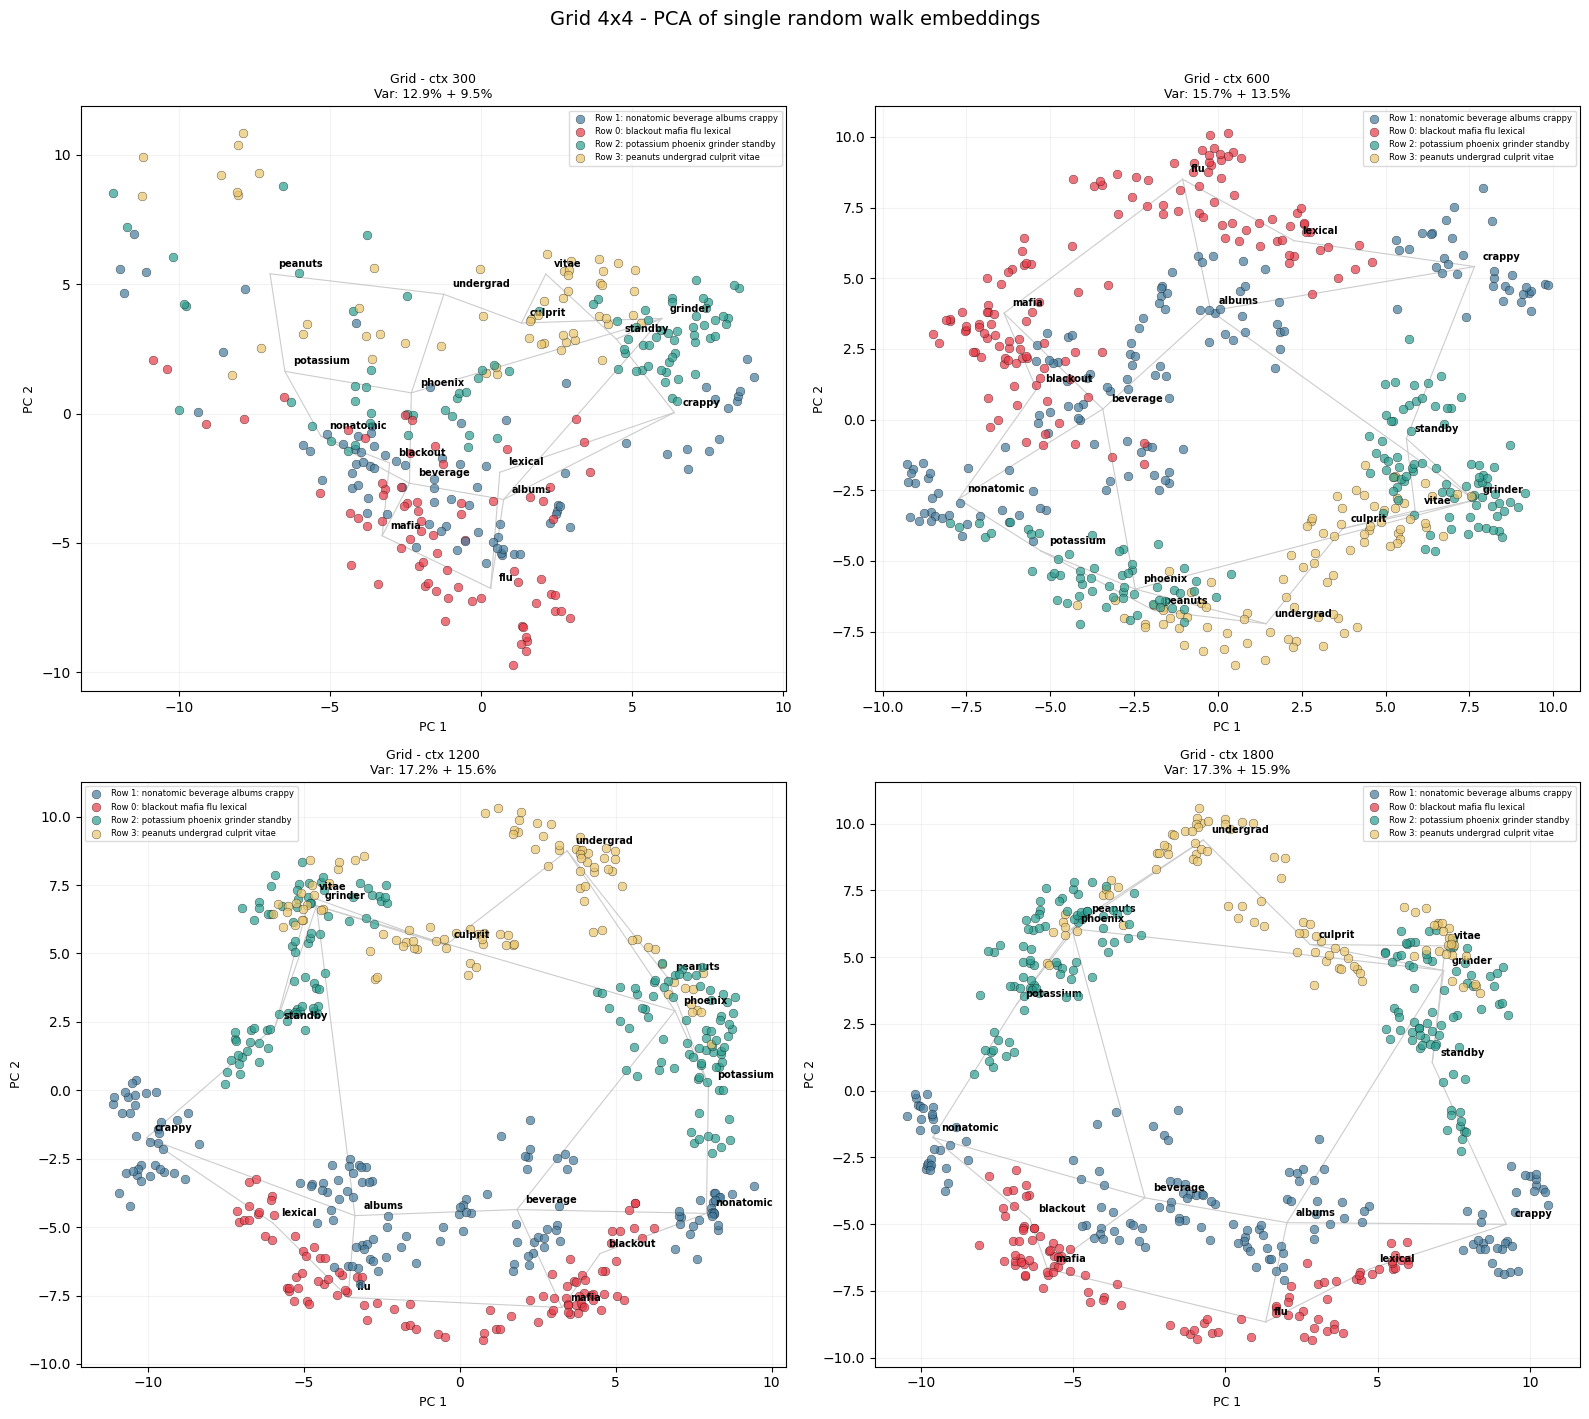

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    plot_pca_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD,
        token_to_group, ROW_COLORS_MAP, ROW_LABELS_MAP,
        all_edges, title=f"Grid - ctx {ctx}",
        NW=500
    )

fig.suptitle("Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Paper Grid

In [4]:
VOCAB_PATH_PAPER = Path("../data/paper-tkid-map.txt")
GRID_PATH_PAPER  = Path("../data/one_random_walk/paper_grid/paper_grid_structure.txt")
EMB_DIR_PAPER    = Path("../embeddings/one_random_walk/paper_grid")

token_to_id_paper, _ = load_token_id_map(VOCAB_PATH_PAPER)
GRID_P, WORD_TO_POS_P, WORD_TO_TID_P, ID_TO_WORD_P, ROW_LABELS_P = \
    load_grid_structure(GRID_PATH_PAPER, token_to_id_paper)

all_edges_p = grid_edges_from_grid(GRID_P, WORD_TO_TID_P)
ROW_COLORS_MAP_P = {i: c for i, c in enumerate(ROW_COLORS)}
ROW_LABELS_MAP_P = {r: f"Row {r}: " + " ".join(GRID_P[r]) for r in range(4)}
token_to_group_p = {w: r for r, row in enumerate(GRID_P) for c, w in enumerate(row)}

print("GRID (paper):")
for row in GRID_P:
    print(row)

GRID (paper):
['apple', 'bird', 'car', 'egg']
['house', 'milk', 'plane', 'opera']
['box', 'sand', 'sun', 'mango']
['rock', 'math', 'code', 'phone']


  [Paper grid - ctx 300] Discarded 2/301 embeddings with unknown token IDs


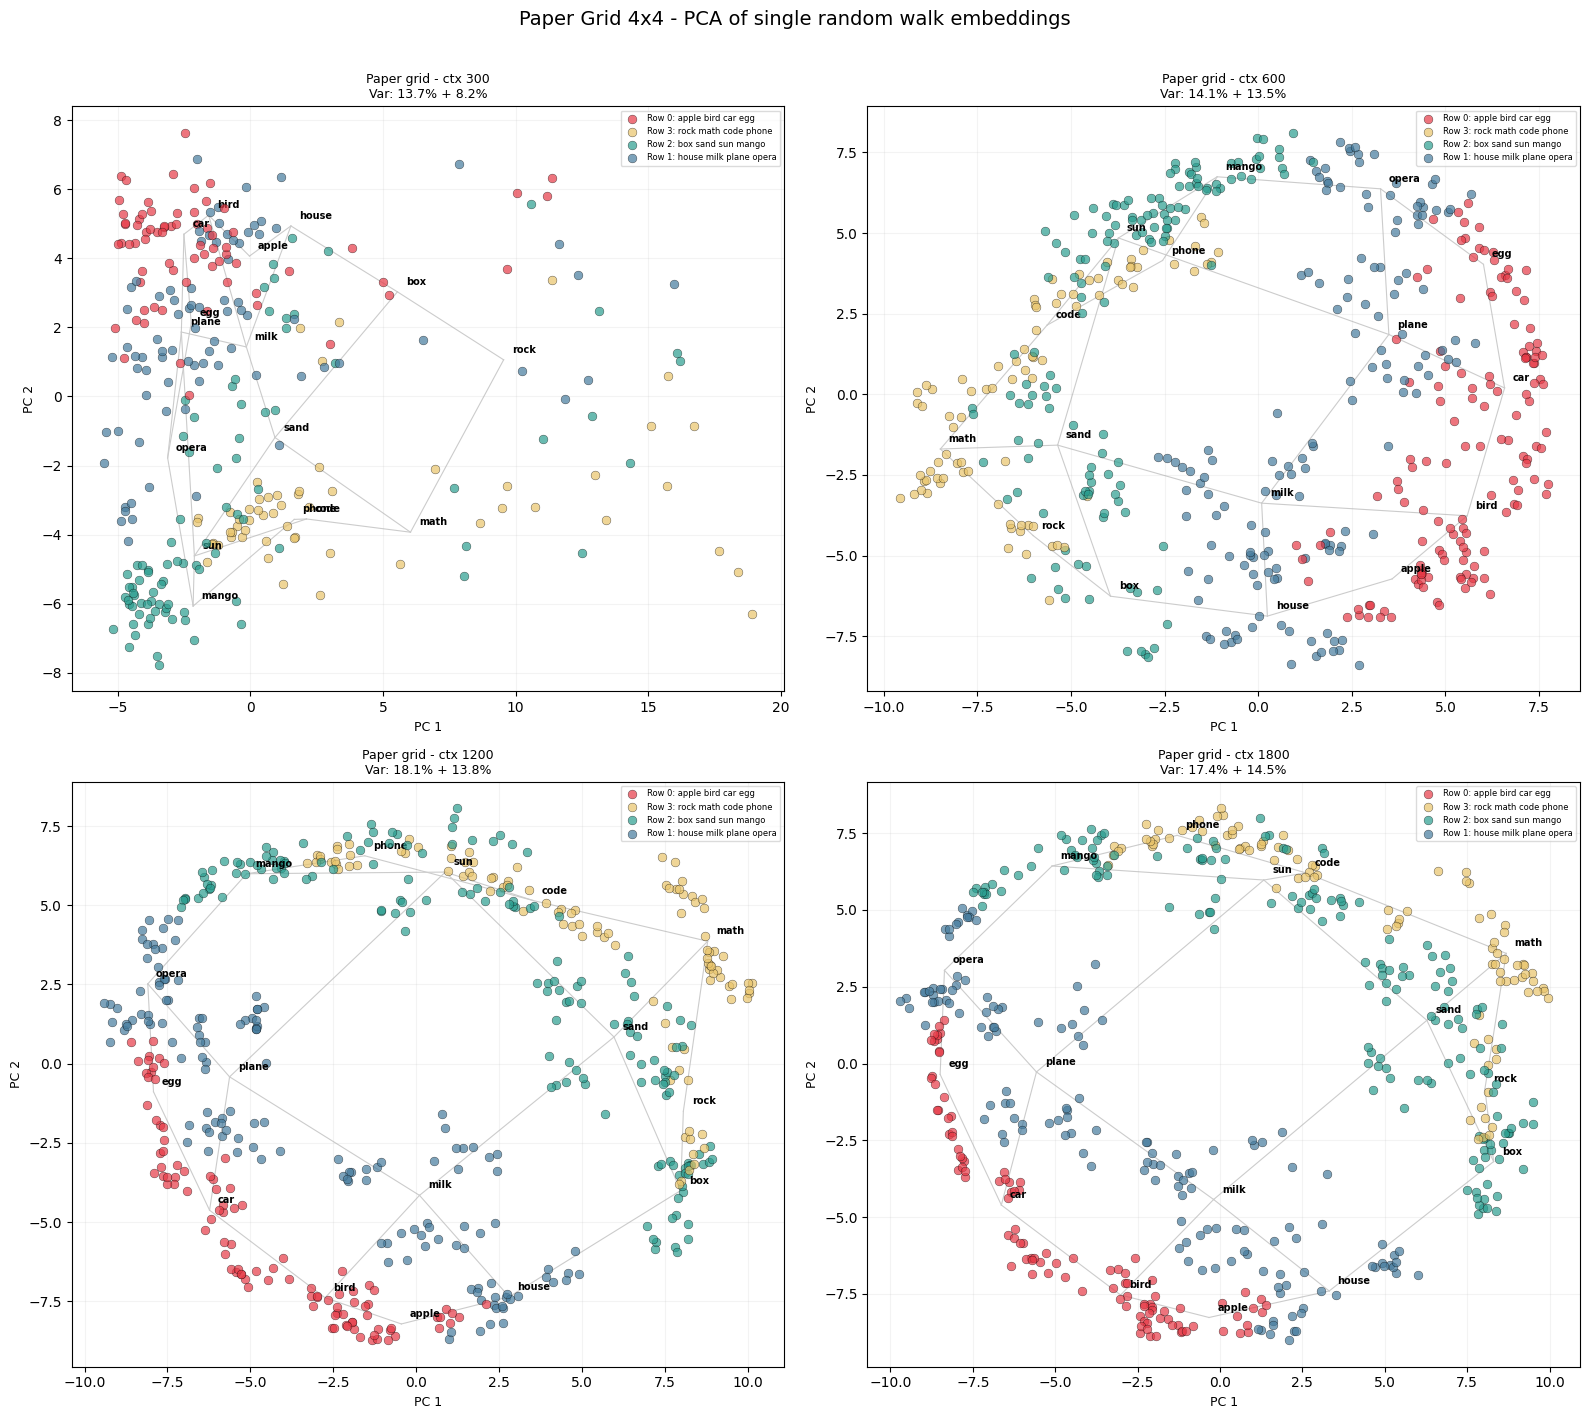

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR_PAPER / f"reprs_paper_grid_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    plot_pca_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_P,
        token_to_group_p, ROW_COLORS_MAP_P, ROW_LABELS_MAP_P,
        all_edges_p, title=f"Paper grid - ctx {ctx}",
    )

fig.suptitle("Paper Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Parametrized Grid 4×4

In [6]:
STRUCT_PATH_PG = Path("../data/one_random_walk/parametrized_grid_16/grid_dataset_structure.txt")
EMB_DIR_PG     = Path("../embeddings/one_random_walk/parametrized_grid_16")

GRID_PG, WORD_TO_POS_PG, WORD_TO_TID_PG, ID_TO_WORD_PG, ROW_LABELS_PG = \
    load_grid_structure(STRUCT_PATH_PG, token_to_id)

all_edges_pg = grid_edges_from_grid(GRID_PG, WORD_TO_TID_PG)
ROW_COLORS_MAP_PG = {i: c for i, c in enumerate(ROW_COLORS)}
ROW_LABELS_MAP_PG = {r: f"Row {r}: " + " ".join(GRID_PG[r]) for r in range(4)}
token_to_group_pg = {w: r for r, row in enumerate(GRID_PG) for c, w in enumerate(row)}

### PCA 2D

  [Parametrized grid - ctx 300] Discarded 3/302 embeddings with unknown token IDs


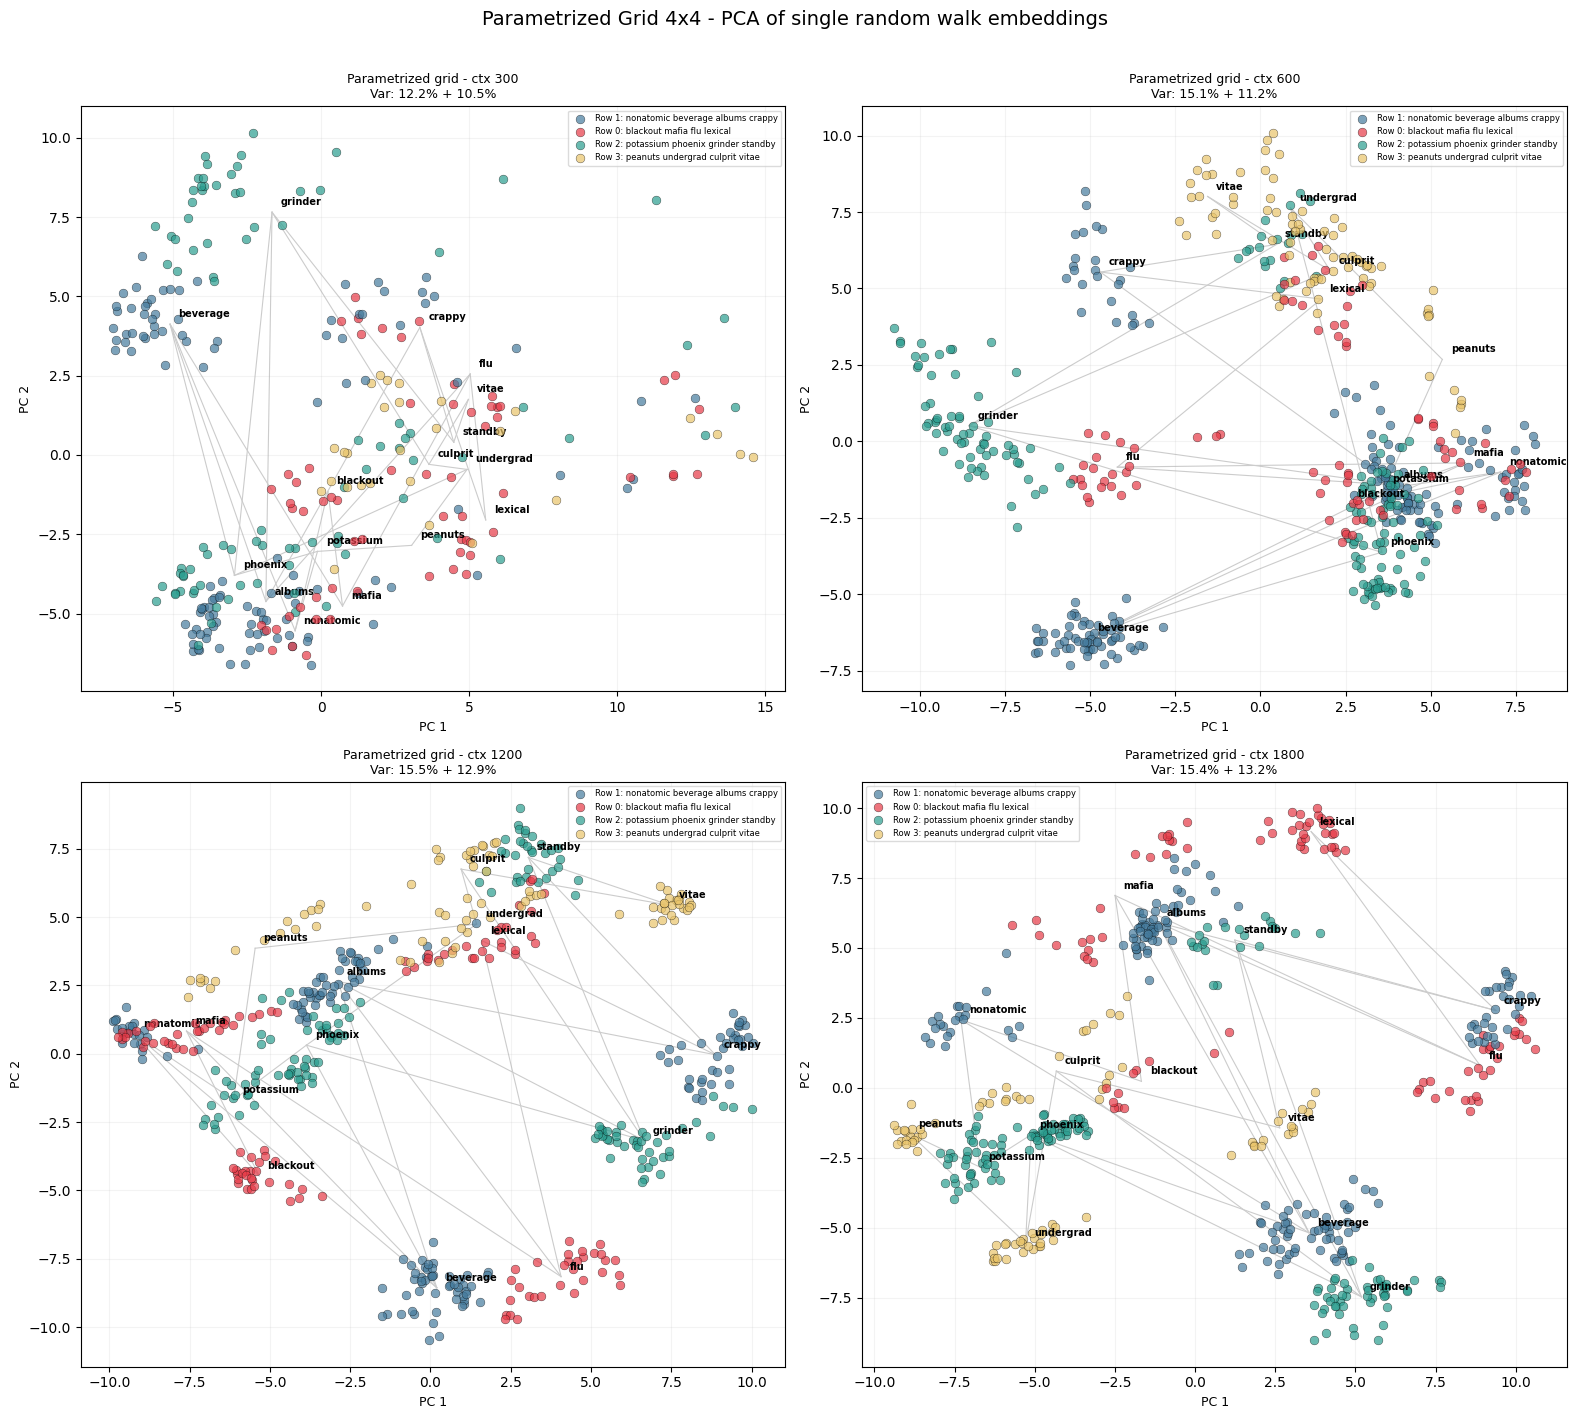

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR_PG / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    plot_pca_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_PG,
        token_to_group_pg, ROW_COLORS_MAP_PG, ROW_LABELS_MAP_PG,
        all_edges_pg, title=f"Parametrized grid - ctx {ctx}",
    )

fig.suptitle("Parametrized Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 2D

  [Parametrized grid UMAP - ctx 300] Discarded 3/302 embeddings with unknown token IDs


/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


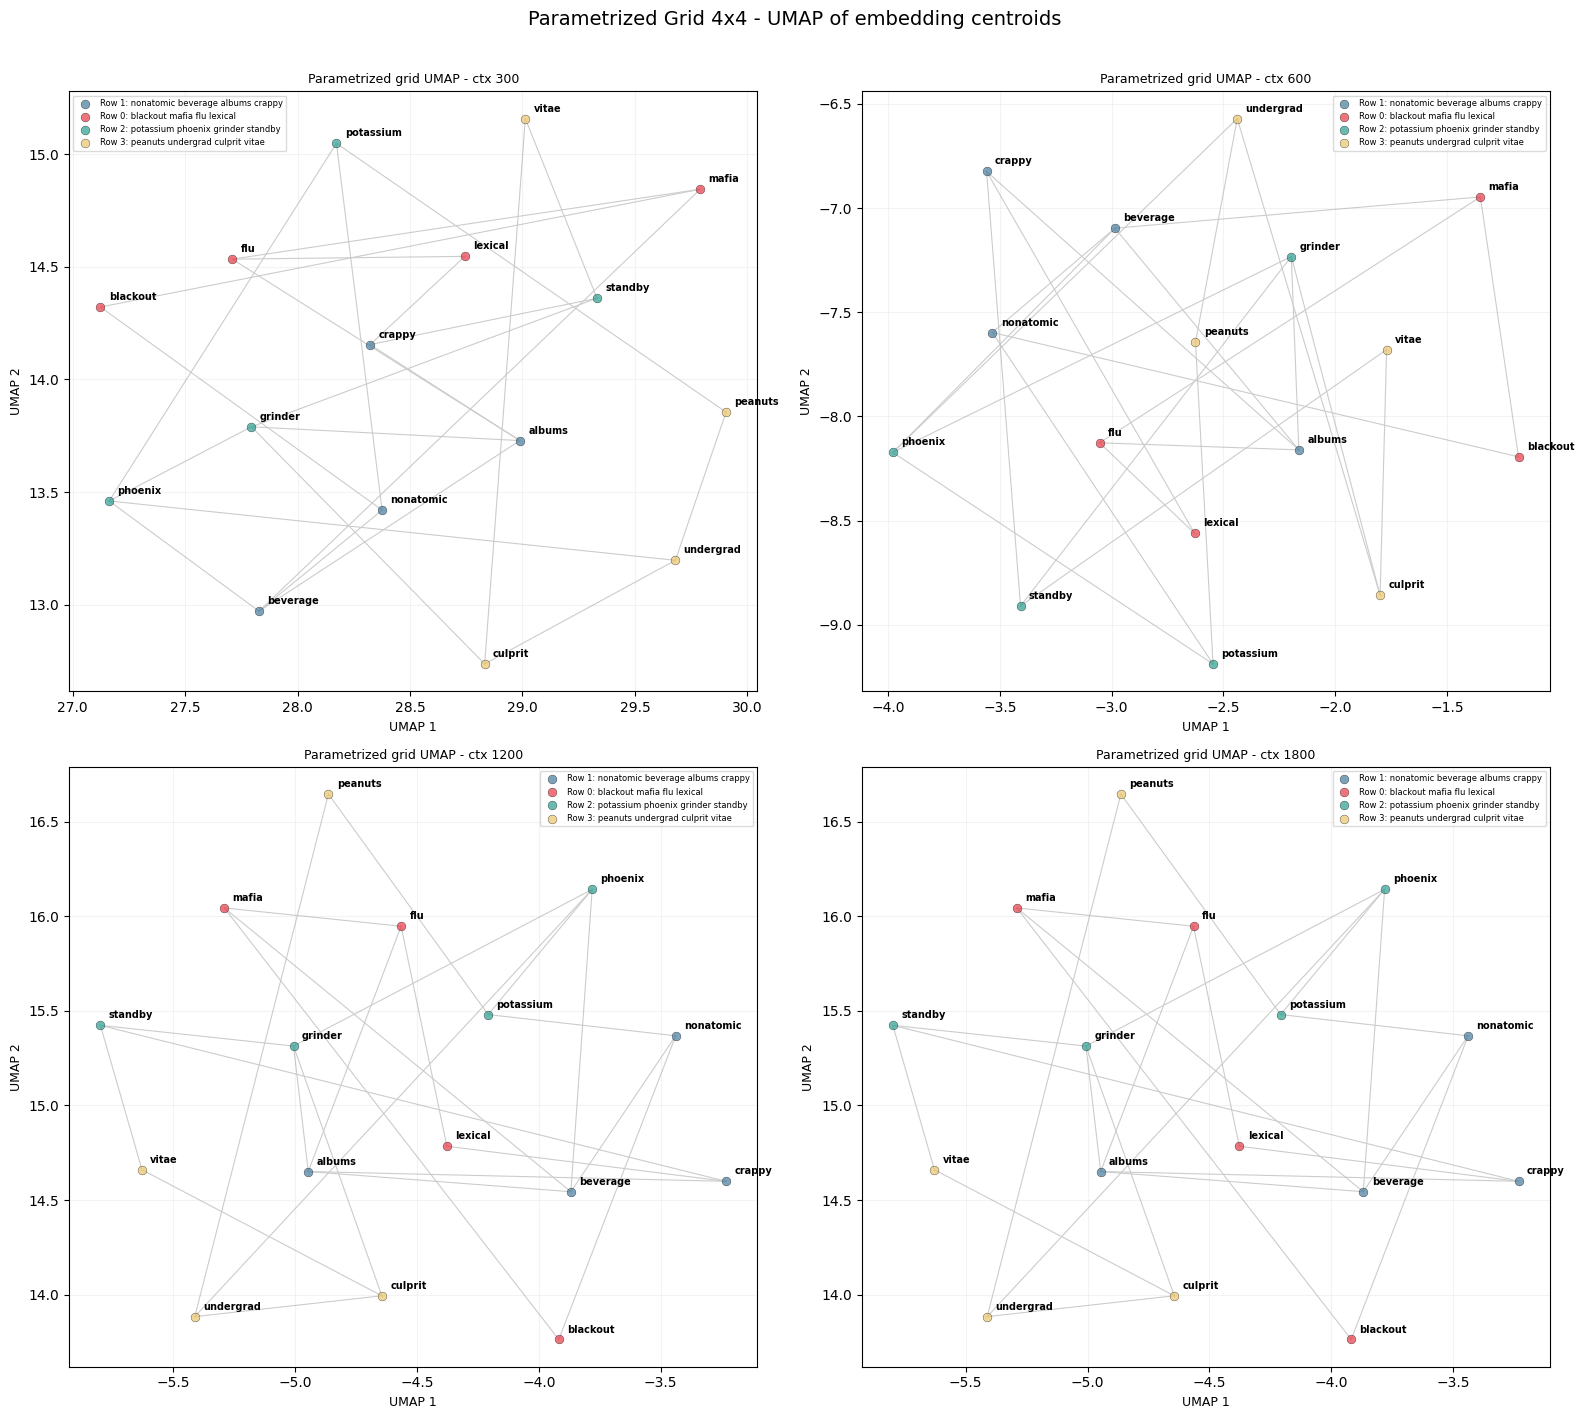

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR_PG / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    plot_umap_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_PG,
        token_to_group_pg, ROW_COLORS_MAP_PG, ROW_LABELS_MAP_PG,
        all_edges_pg, title=f"Parametrized grid UMAP - ctx {ctx}",
    )

fig.suptitle("Parametrized Grid 4x4 - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Torus 4x4

In [9]:
STRUCT_PATH_T = Path("../data/one_random_walk/torus_16/torus_dataset_structure.txt")
EMB_DIR_T     = Path("../embeddings/one_random_walk/torus_16")

GRID_T, WORD_TO_POS_T, WORD_TO_TID_T, ID_TO_WORD_T, ROW_LABELS_T = \
    load_grid_structure(STRUCT_PATH_T, token_to_id)

all_edges_t = torus_edges_from_grid(GRID_T, WORD_TO_TID_T)
ROW_COLORS_MAP_T = {i: c for i, c in enumerate(ROW_COLORS)}
ROW_LABELS_MAP_T = {r: f"Row {r}: " + " ".join(GRID_T[r]) for r in range(4)}
token_to_group_t = {w: r for r, row in enumerate(GRID_T) for c, w in enumerate(row)}

### PCA 3D

  [Torus - ctx 300] Discarded 3/302 embeddings with unknown token IDs


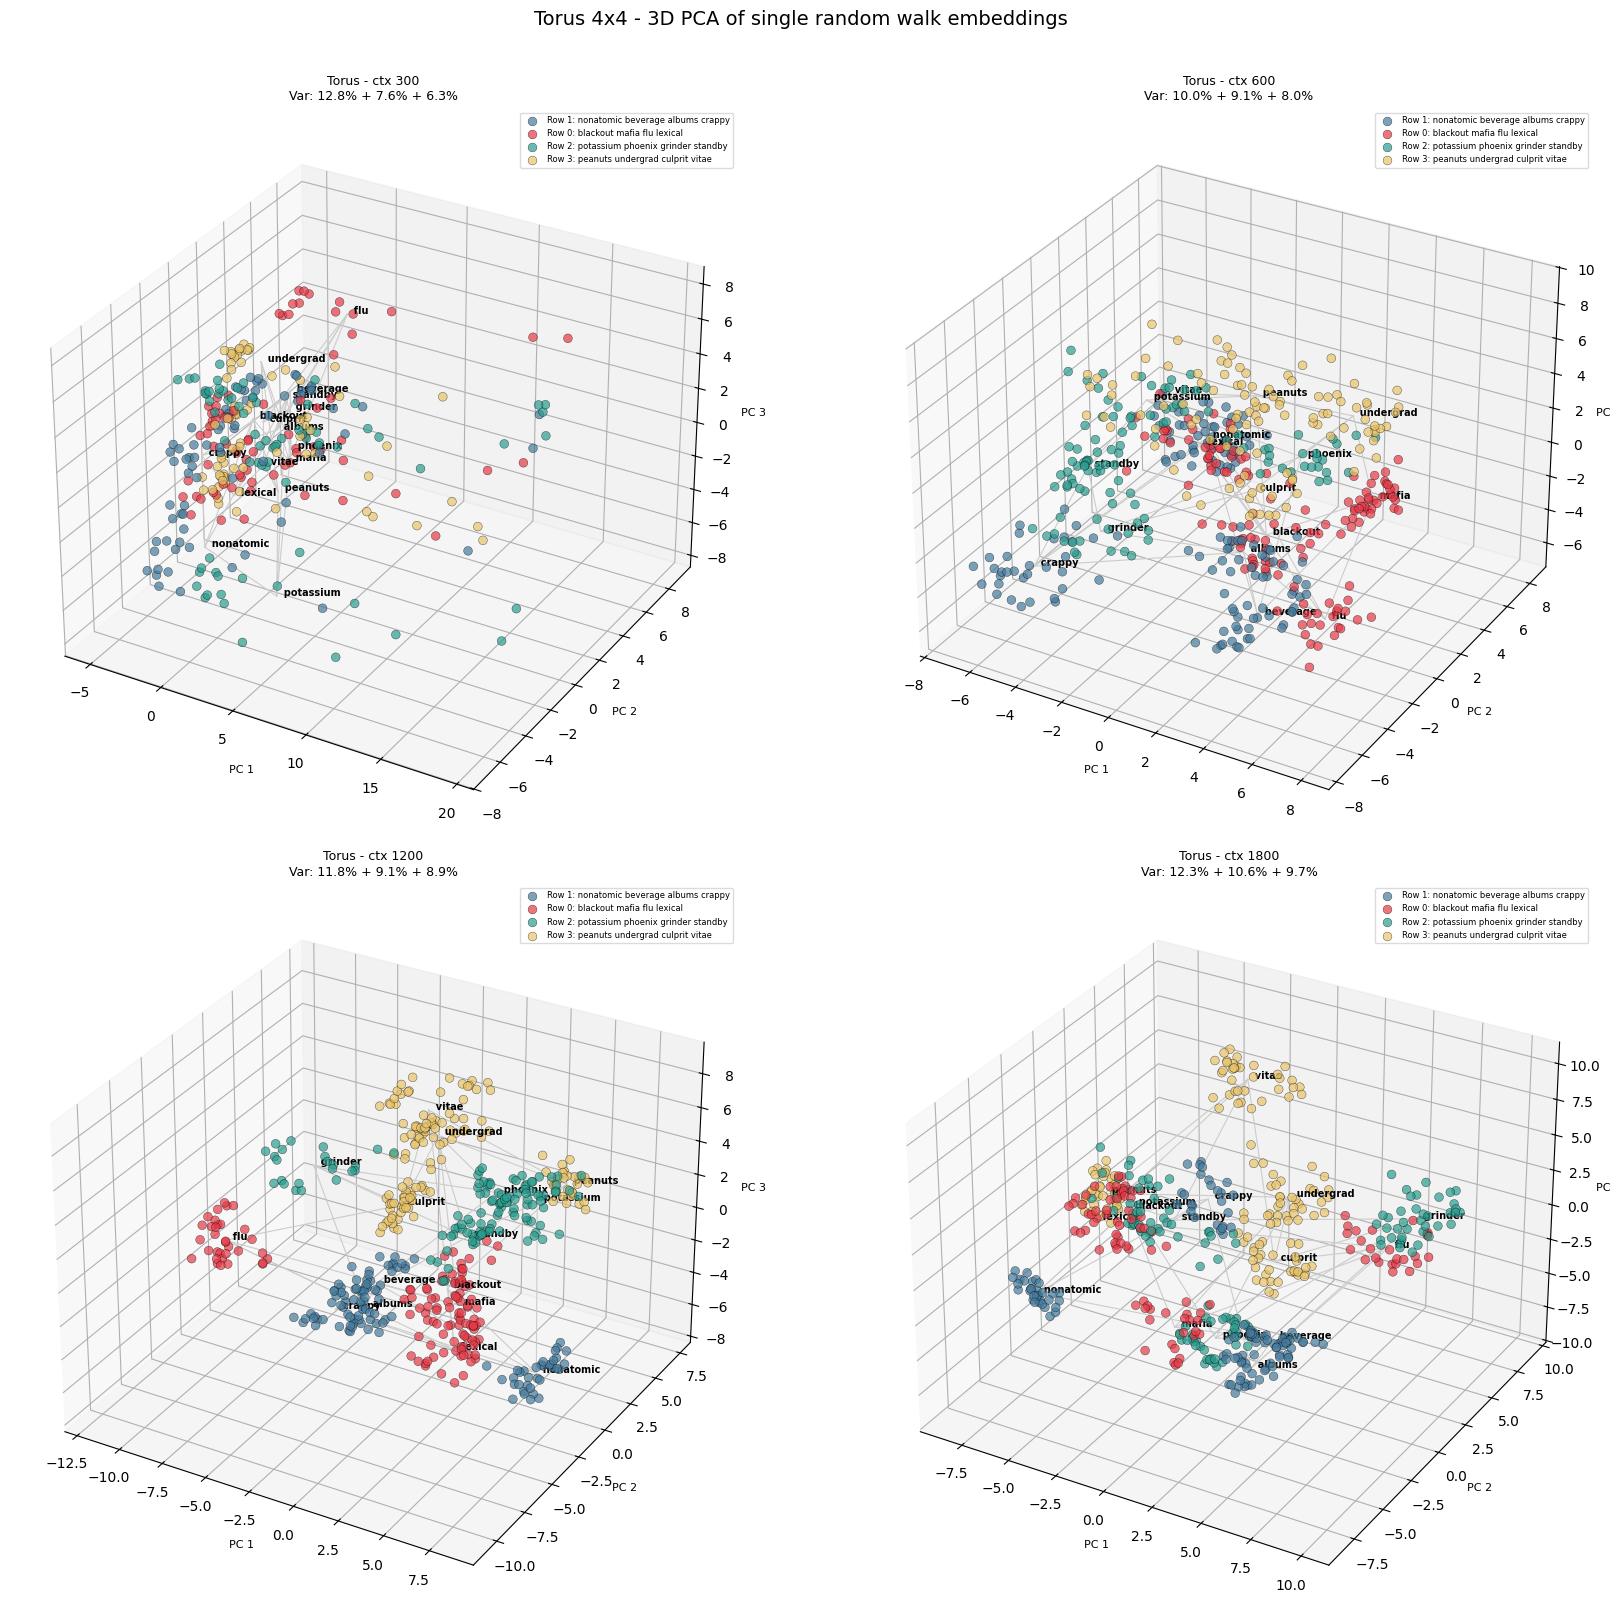

In [10]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    pt_path = EMB_DIR_T / f"reprs_torus_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    plot_pca_3d_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_T,
        token_to_group_t, ROW_COLORS_MAP_T, ROW_LABELS_MAP_T,
        all_edges_t, title=f"Torus - ctx {ctx}",
    )

fig.suptitle("Torus 4x4 - 3D PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 3D

  [Torus UMAP - ctx 300] Discarded 3/302 embeddings with unknown token IDs


/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


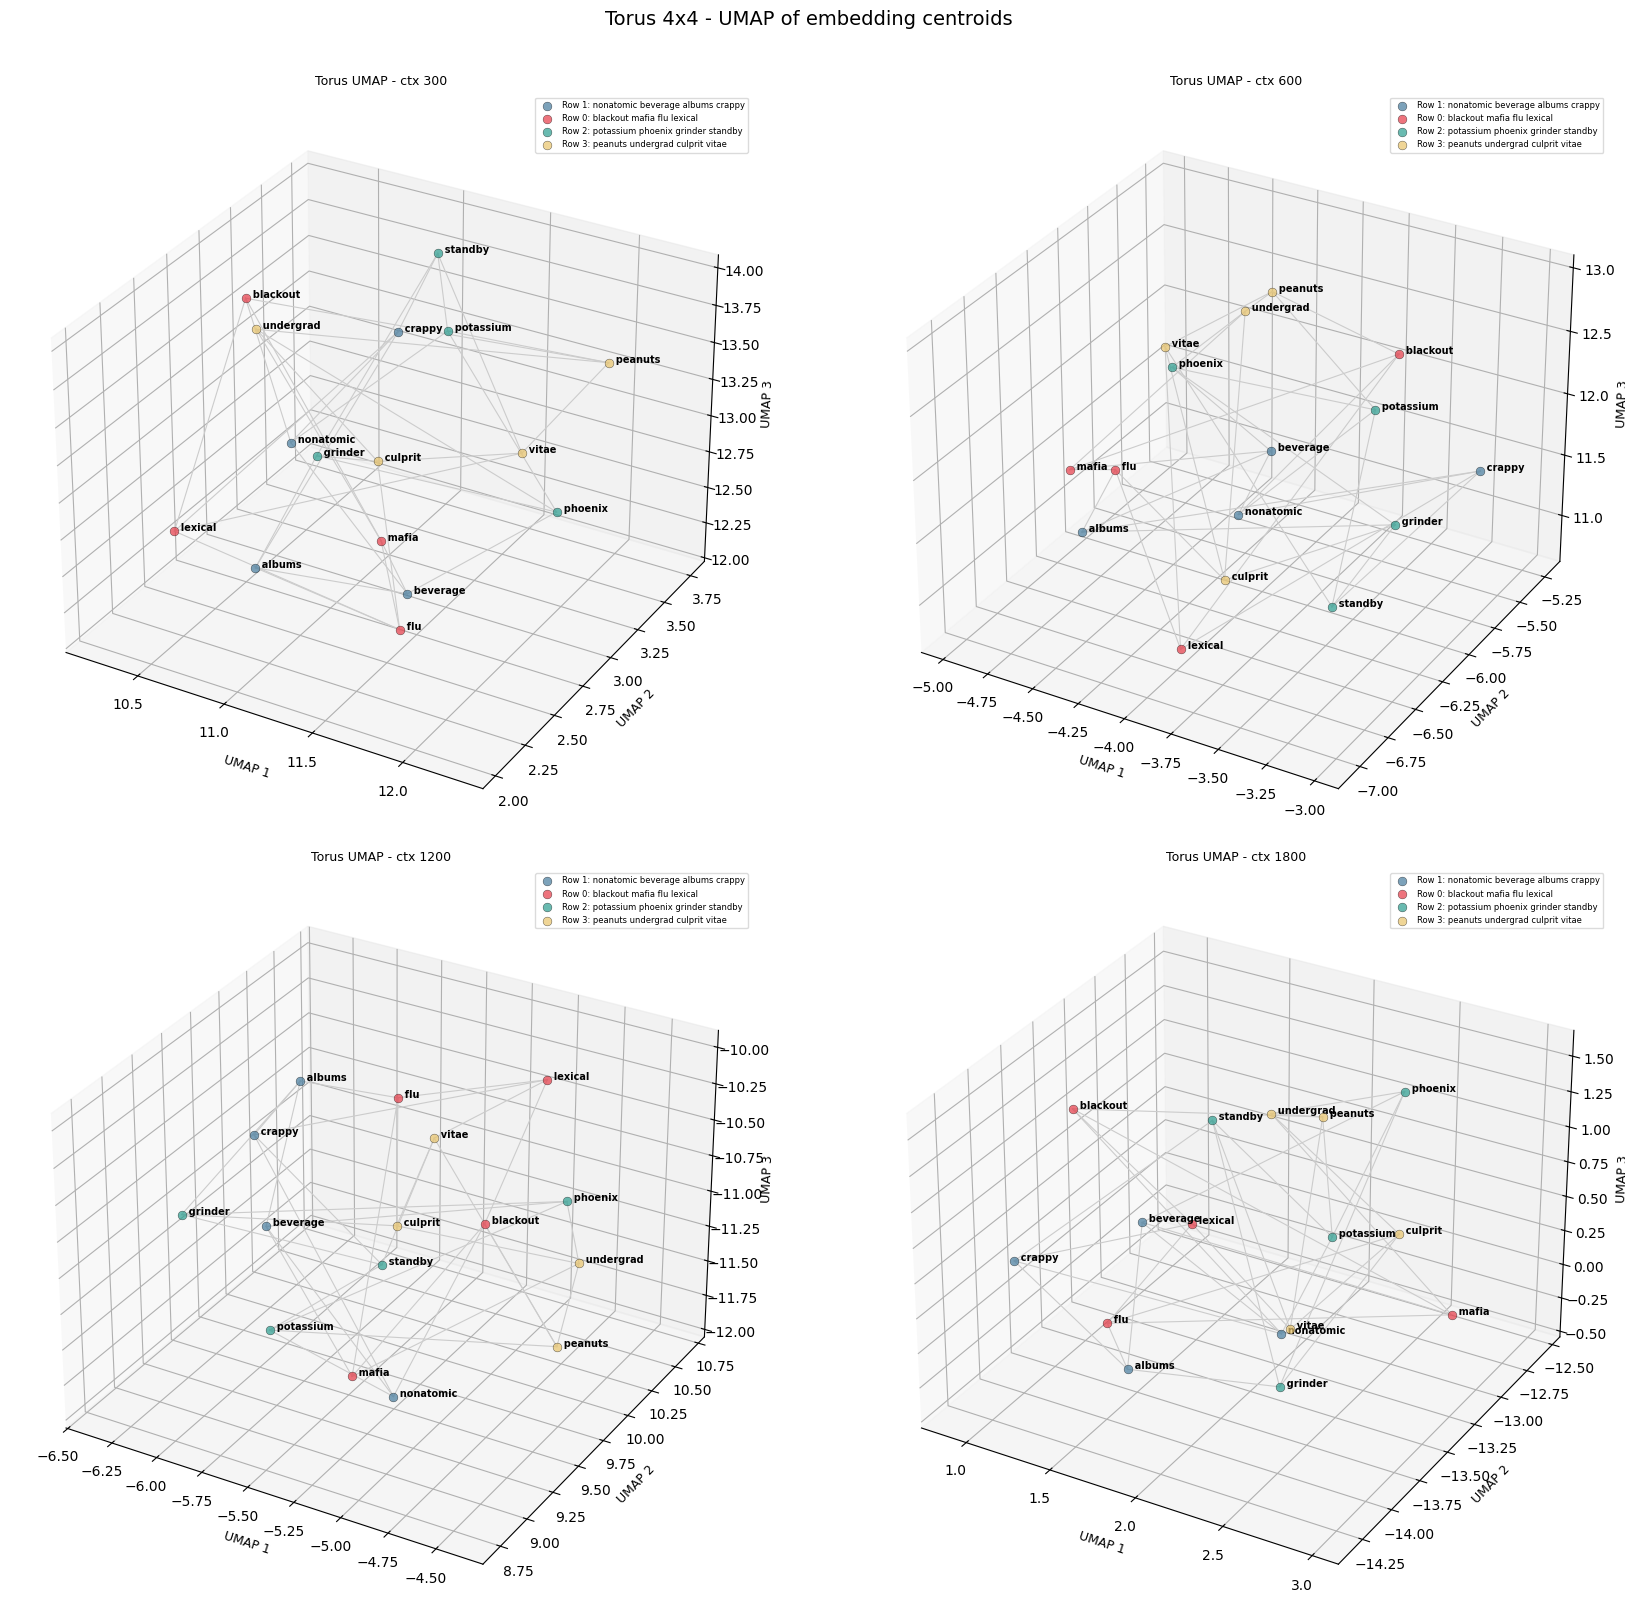

In [11]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    pt_path = EMB_DIR_T / f"reprs_torus_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    plot_umap_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_T,
        token_to_group_t, ROW_COLORS_MAP_T, ROW_LABELS_MAP_T,
        all_edges_t, title=f"Torus UMAP - ctx {ctx}",
        n_components=3,
    )

fig.suptitle("Torus 4x4 - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# Multi-batch Grid Embeddings

Same grid structures as above, but using **multi-batch** embeddings.
For each context length we load **B** independent random-walk files (one per
grid node), take the last **NW** tokens from each, concatenate, and pass the
pooled embeddings to the same plotting routines.

In [12]:
NW_BATCH = 50  # recent-window length per batch element

## Grid 4×4 (multi-batch)

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


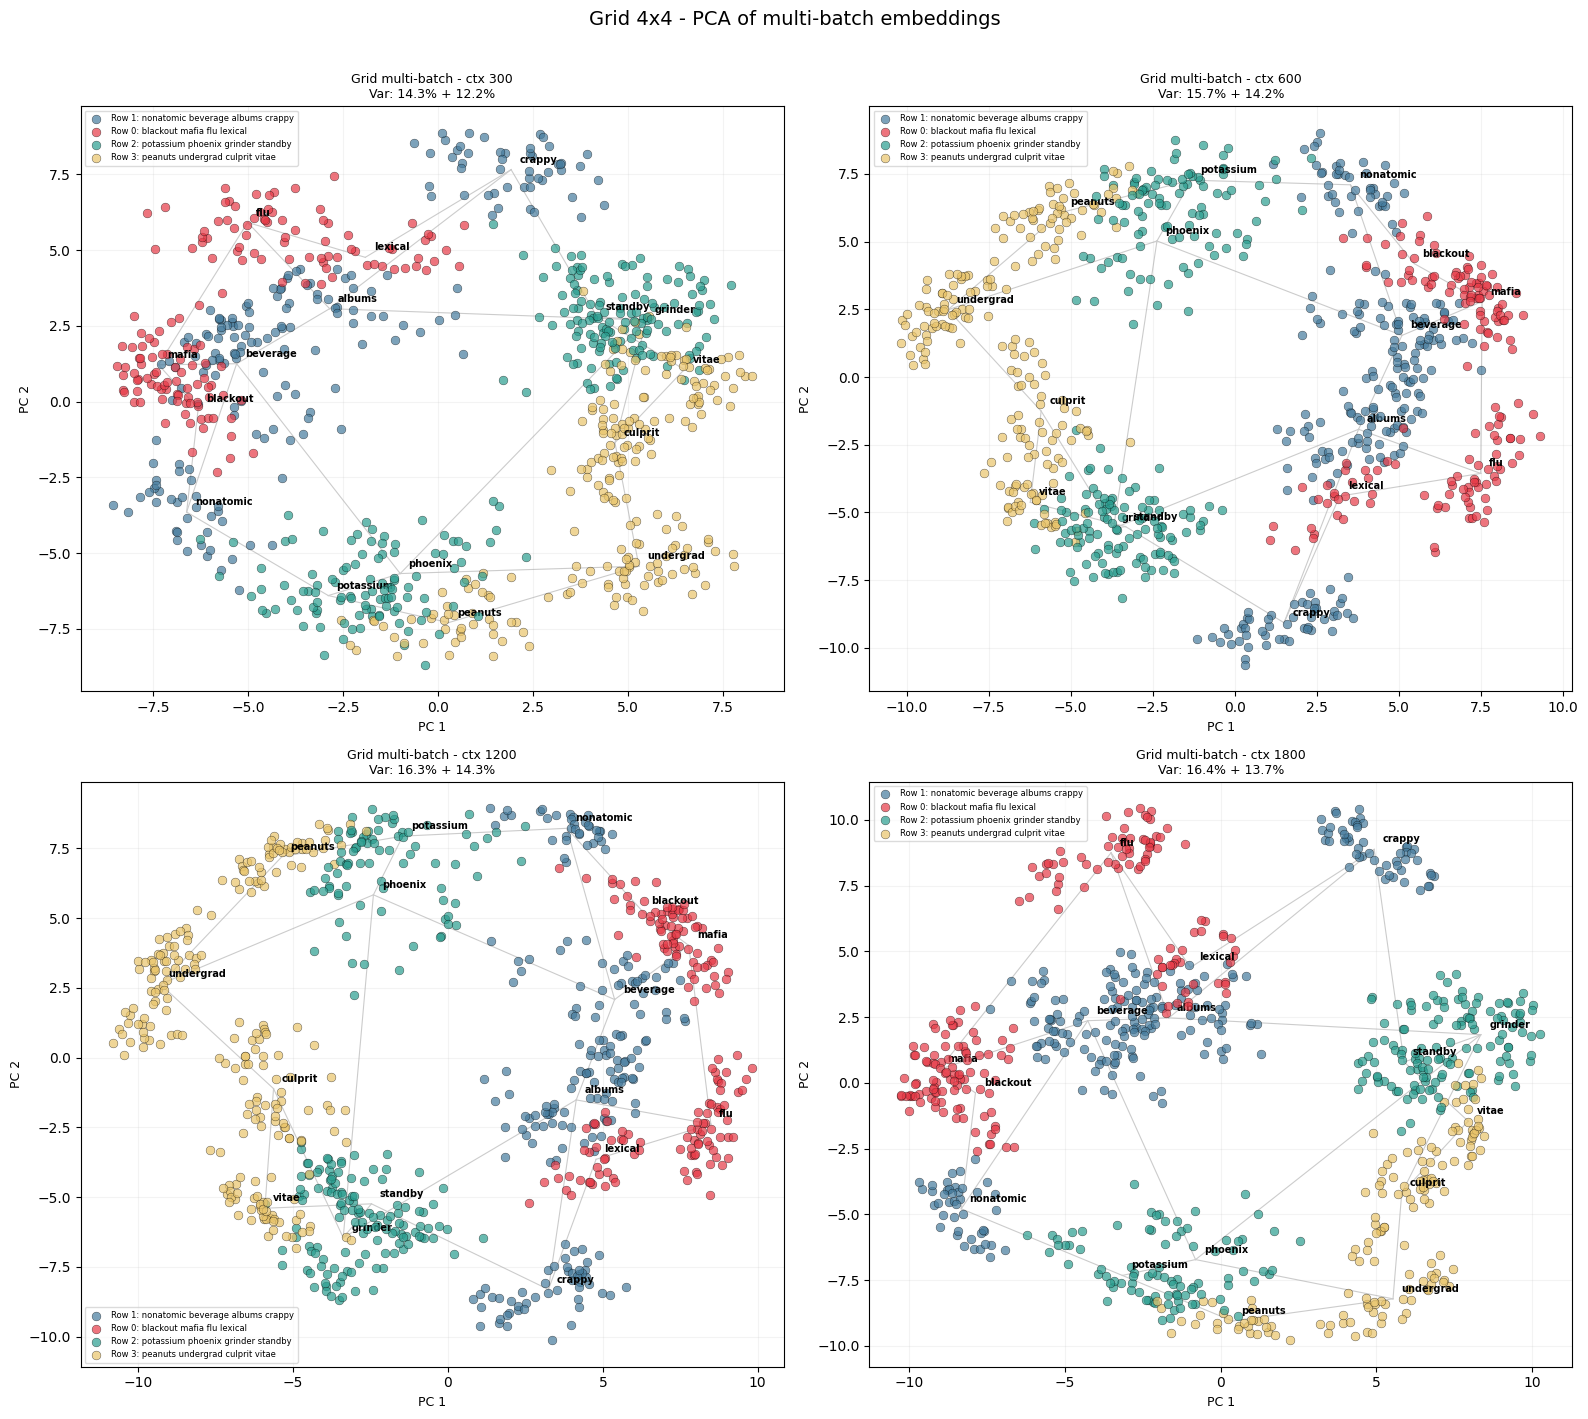

In [13]:
EMB_DIR_MB = Path("../embeddings/multi_batch/grid_16")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB, ctx, NW=NW_BATCH)
    plot_pca_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD,
        token_to_group, ROW_COLORS_MAP, ROW_LABELS_MAP,
        all_edges, NW=len(ids_np), title=f"Grid multi-batch - ctx {ctx}",
    )

fig.suptitle("Grid 4x4 - PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Paper Grid (multi-batch)

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


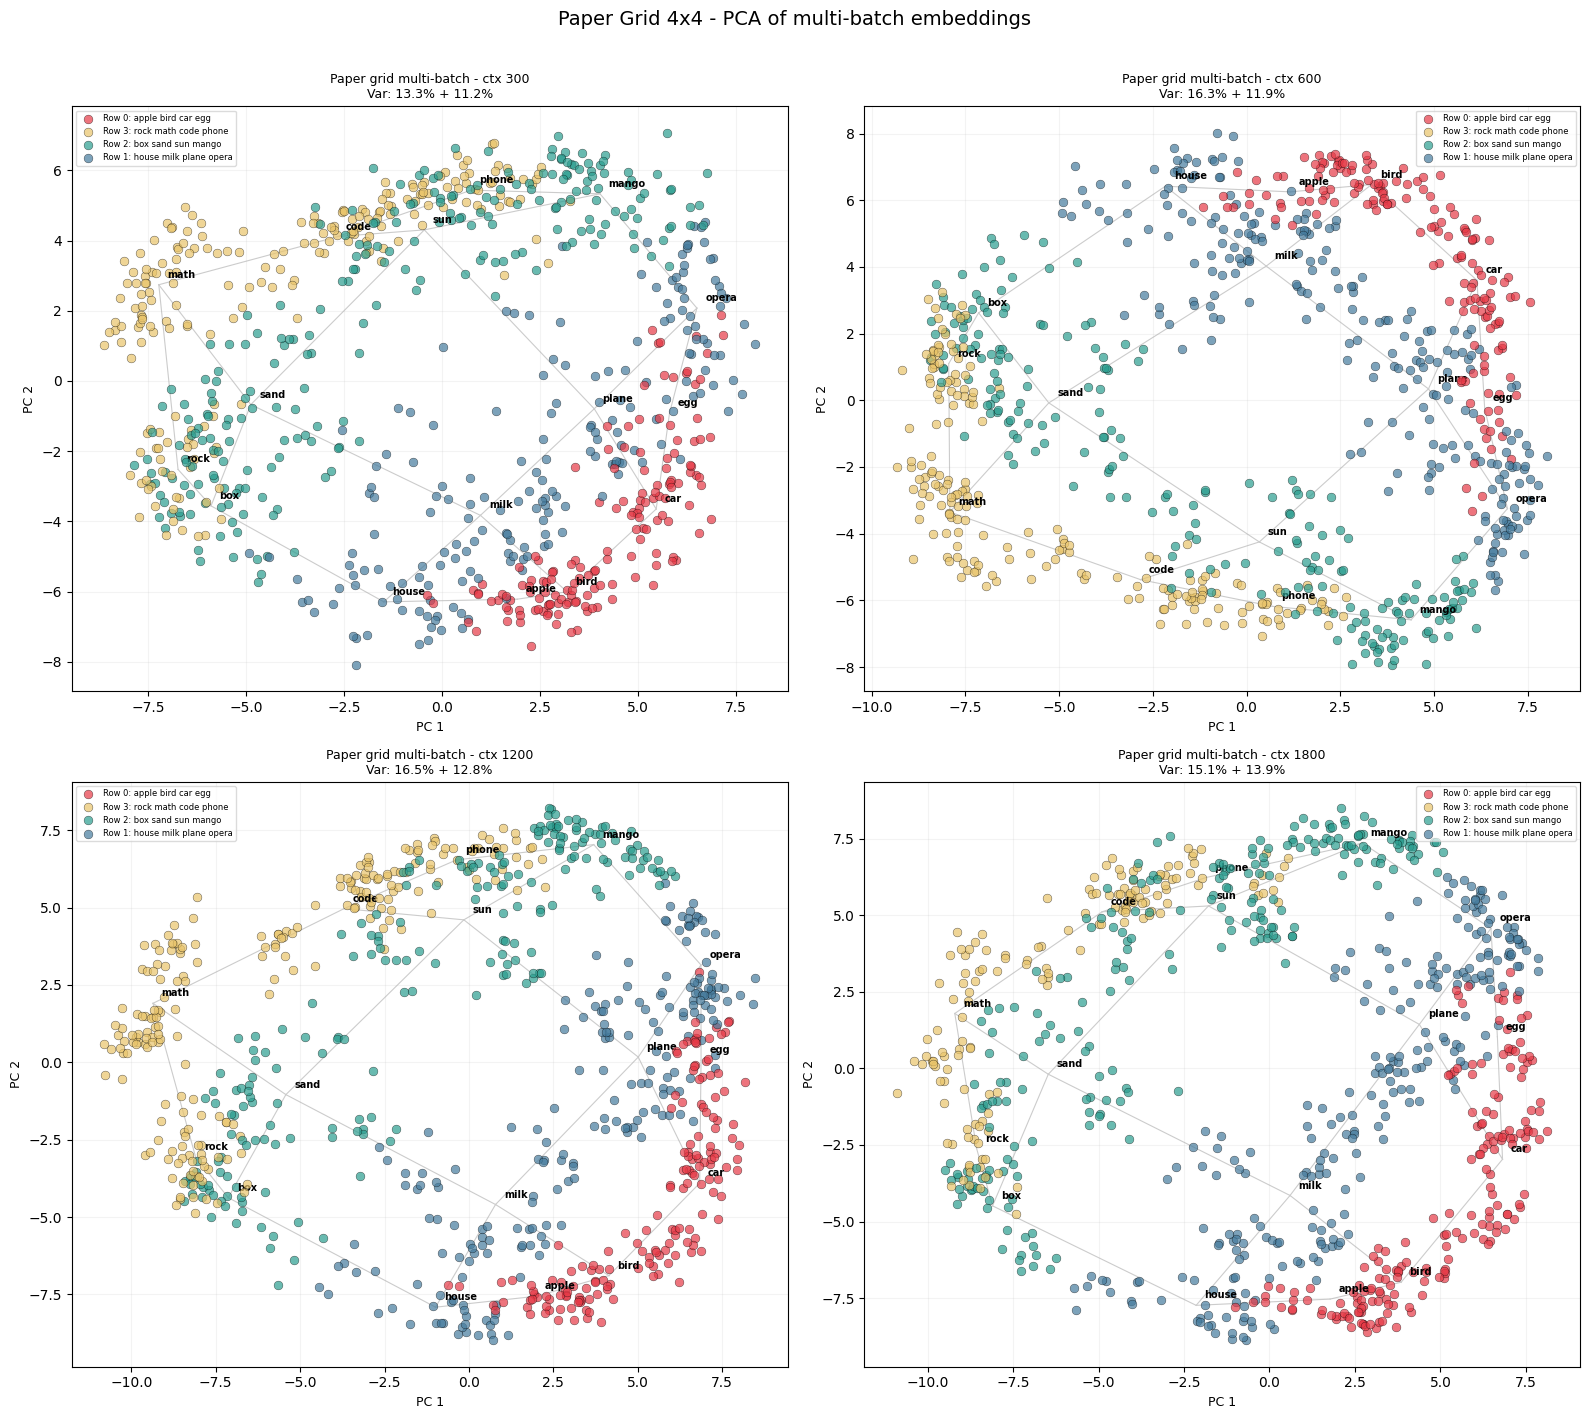

In [14]:
EMB_DIR_MB_P = Path("../embeddings/multi_batch/paper_grid")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_P, ctx, NW=NW_BATCH)
    plot_pca_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_P,
        token_to_group_p, ROW_COLORS_MAP_P, ROW_LABELS_MAP_P,
        all_edges_p, NW=len(ids_np), title=f"Paper grid multi-batch - ctx {ctx}",
    )

fig.suptitle("Paper Grid 4x4 - PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Parametrized Grid 4×4 (multi-batch)

### PCA 2D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


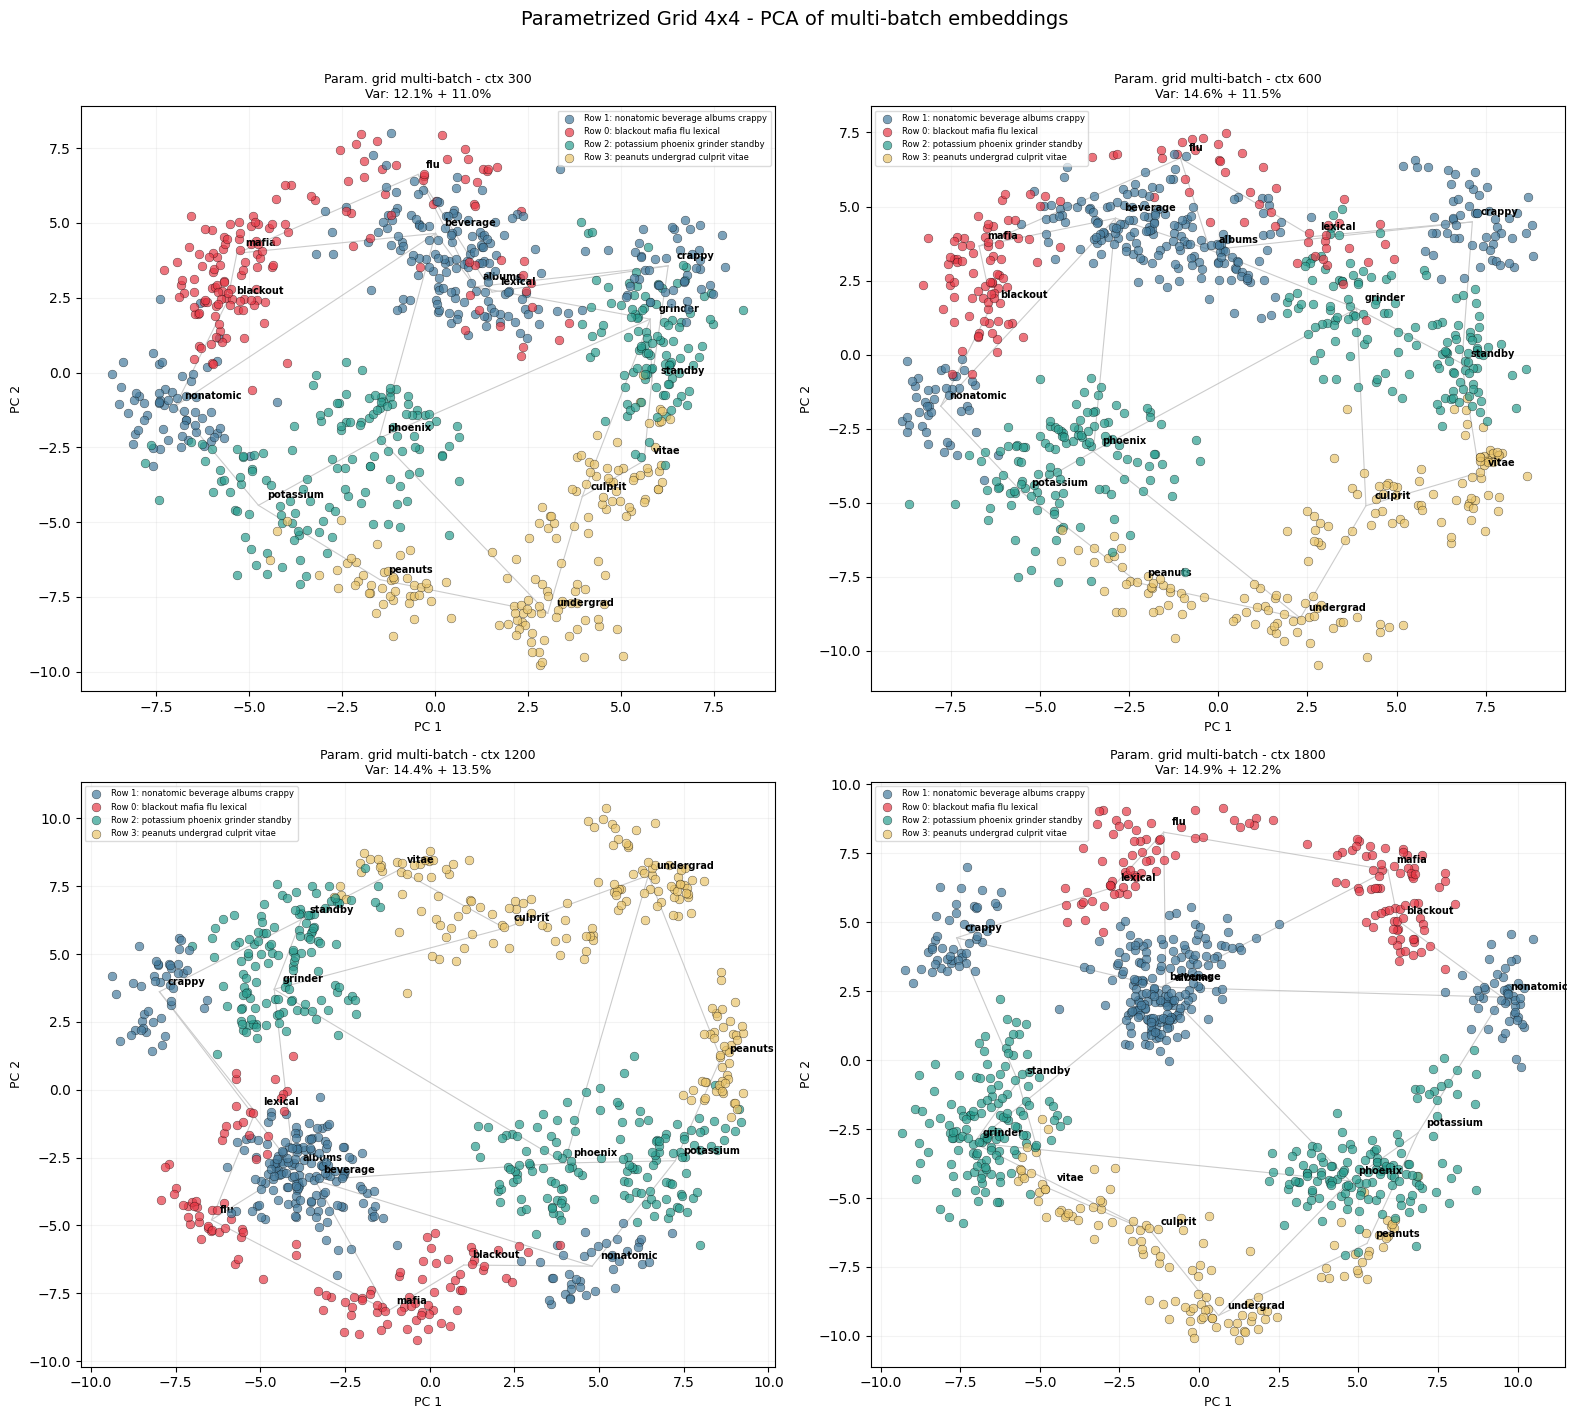

In [15]:
EMB_DIR_MB_PG = Path("../embeddings/multi_batch/parametrized_grid_16")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_PG, ctx, NW=NW_BATCH)
    plot_pca_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_PG,
        token_to_group_pg, ROW_COLORS_MAP_PG, ROW_LABELS_MAP_PG,
        all_edges_pg, NW=len(ids_np), title=f"Param. grid multi-batch - ctx {ctx}",
    )

fig.suptitle("Parametrized Grid 4x4 - PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 2D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


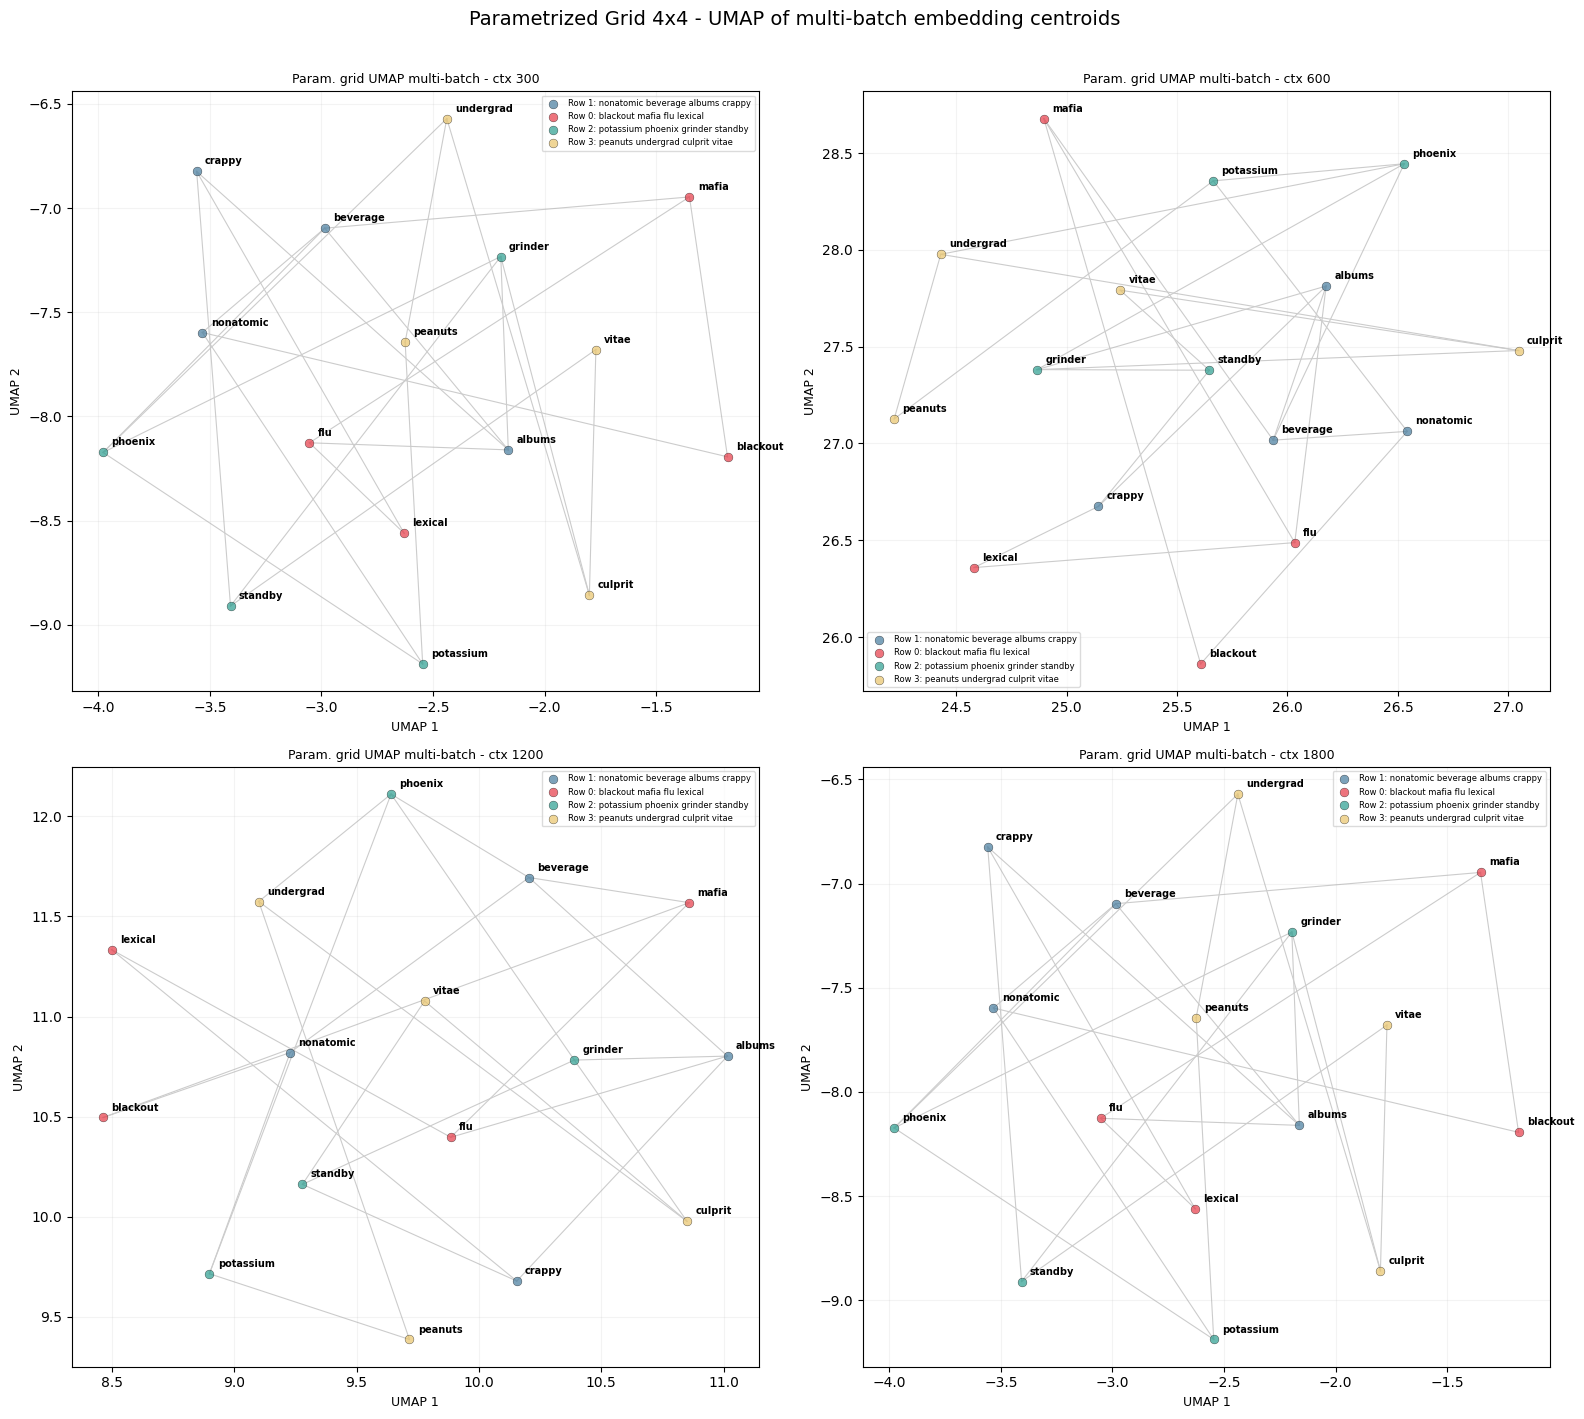

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_PG, ctx, NW=NW_BATCH)
    plot_umap_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_PG,
        token_to_group_pg, ROW_COLORS_MAP_PG, ROW_LABELS_MAP_PG,
        all_edges_pg, NW=len(ids_np), title=f"Param. grid UMAP multi-batch - ctx {ctx}",
    )

fig.suptitle("Parametrized Grid 4x4 - UMAP of multi-batch embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Torus 4×4 (multi-batch)

### PCA 3D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


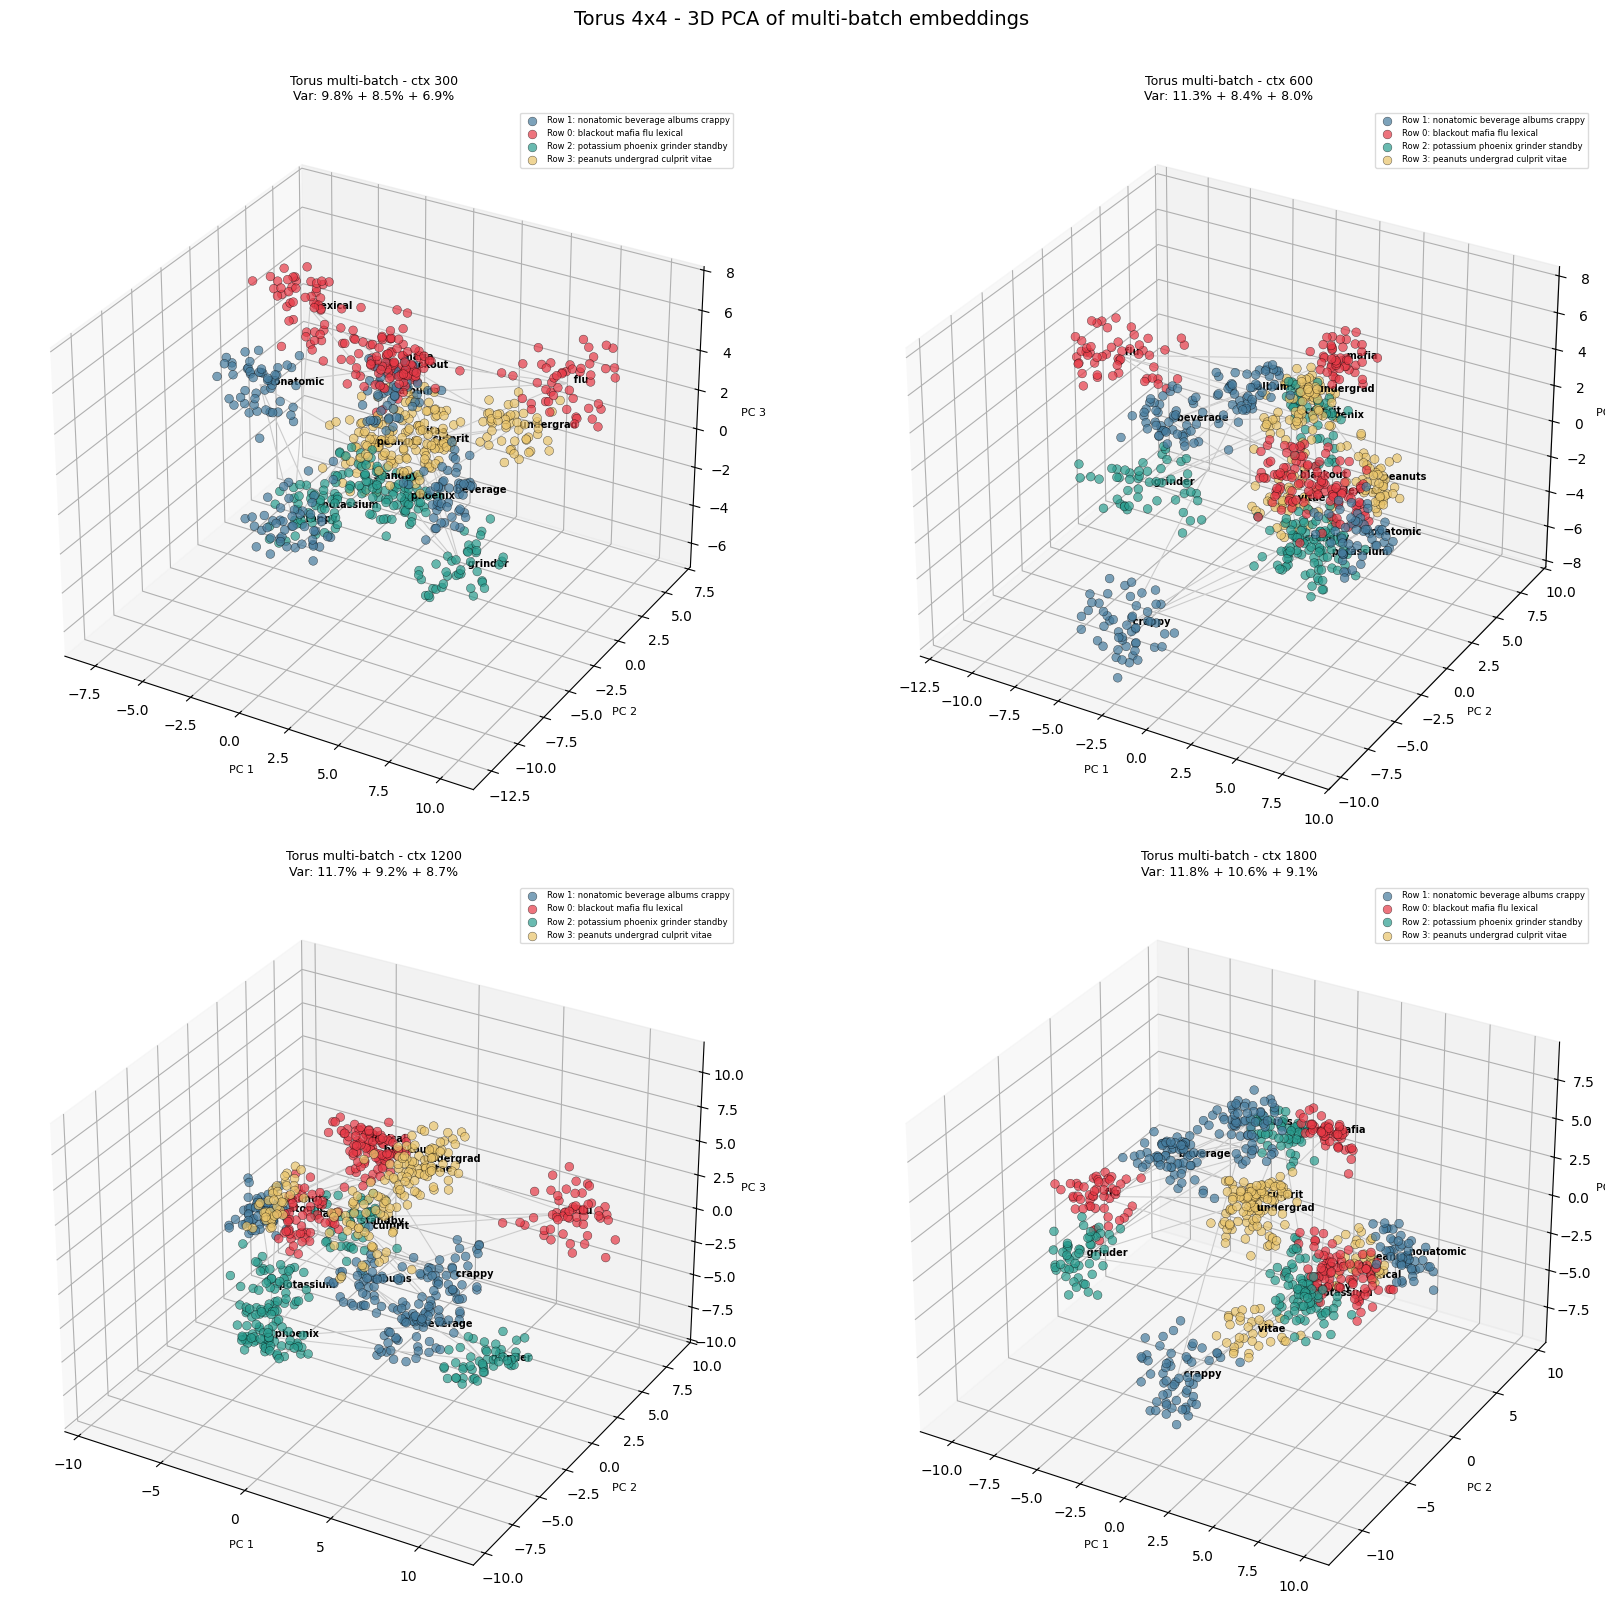

In [17]:
EMB_DIR_MB_T = Path("../embeddings/multi_batch/torus_16")

fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_T, ctx, NW=NW_BATCH)
    plot_pca_3d_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_T,
        token_to_group_t, ROW_COLORS_MAP_T, ROW_LABELS_MAP_T,
        all_edges_t, NW=len(ids_np), title=f"Torus multi-batch - ctx {ctx}",
    )

fig.suptitle("Torus 4x4 - 3D PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 3D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/giaco/Documents/projects/NLP/hico/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


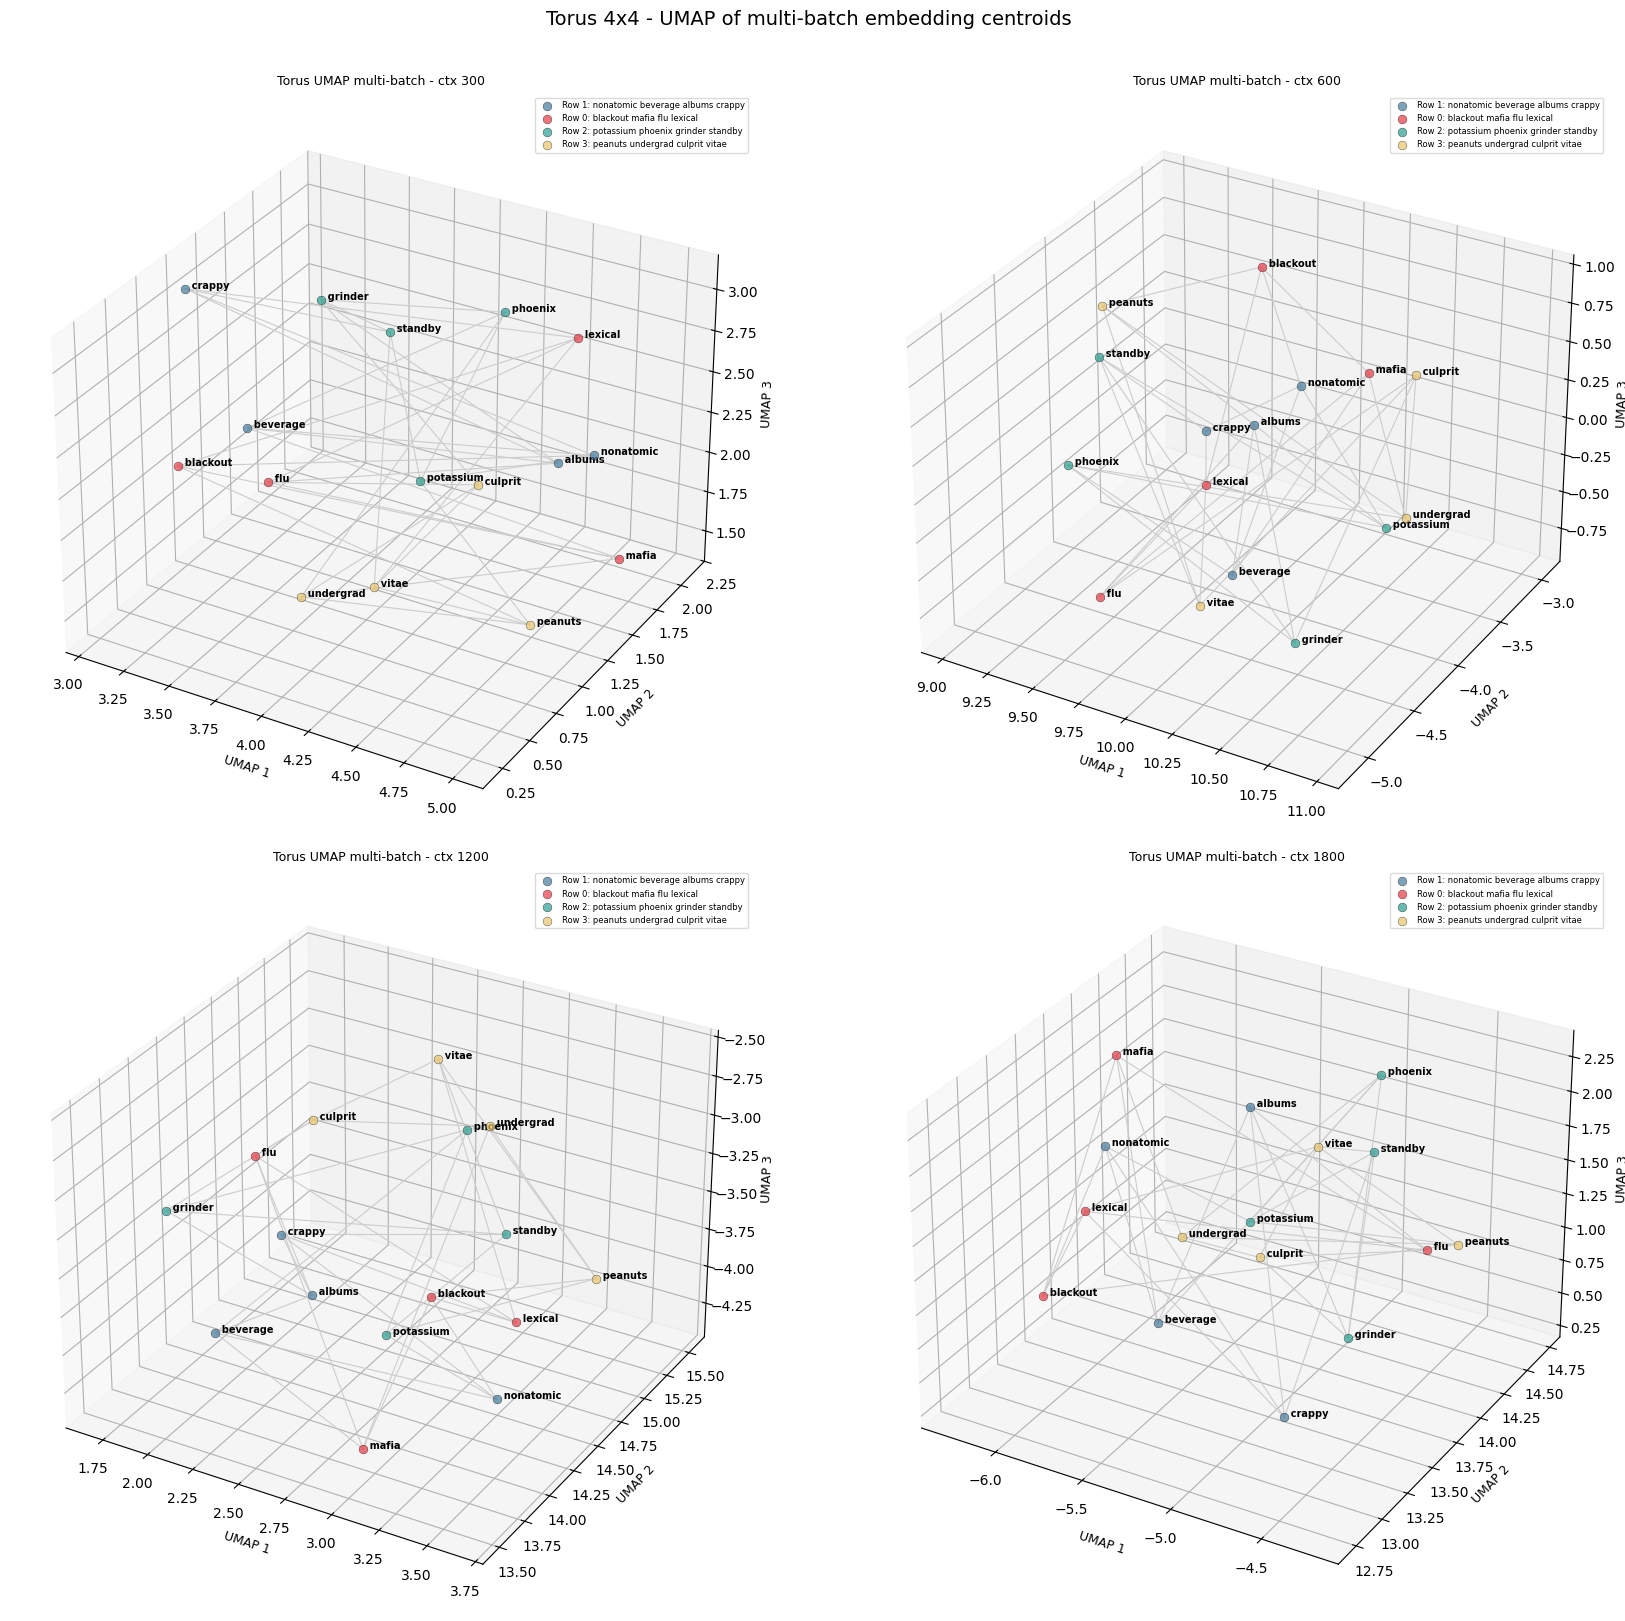

In [18]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_T, ctx, NW=NW_BATCH)
    plot_umap_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD_T,
        token_to_group_t, ROW_COLORS_MAP_T, ROW_LABELS_MAP_T,
        all_edges_t, NW=len(ids_np), title=f"Torus UMAP multi-batch - ctx {ctx}",
        n_components=3,
    )

fig.suptitle("Torus 4x4 - UMAP of multi-batch embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()